# Tugas 2 - Klasifikasi Diabetes dengan Naive Bayes dan Logistic Regression

| Nama | NRP |
|------|-----|
| Sulaiman Faiz Tsaqib | 5054251048|

## Deskripsi Tugas
Pada tugas ini, kita akan menggunakan Pima Indians Diabetes Dataset. Dataset bisa diakses melalui link berikut:\
https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

Tujuan utama dari tugas ini adalah membangun model Naive Bayes dan Logistic Regression untuk mengklasifikasikan apakah seorang pasien menderita diabetes atau tidak.

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model.
3. Eksperimen Model
   - Bangun model Gaussian Naive Bayes dan Logistic Regression.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil kedua model dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix, roc_curve, roc_auc_score)

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('diabetes.csv')
print(df.shape)
df.head()

(768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


In [4]:
print("Missing value (NaN) per kolom:")
print(df.isnull().sum())
df.describe()

Missing value (NaN) per kolom:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


Outcome
0    500
1    268
Name: count, dtype: int64
Outcome
0    65.104167
1    34.895833
Name: count, dtype: float64


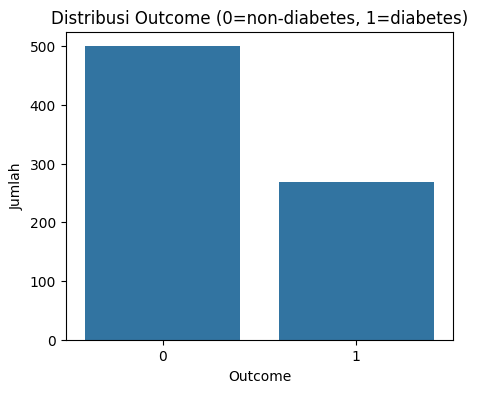

In [5]:
# Tampilkan distribusi kelas target (Outcome) dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
outcome_counts = df['Outcome'].value_counts()
print(outcome_counts)
print(outcome_counts / len(df) * 100)

plt.figure(figsize=(5, 4))
sns.countplot(x='Outcome', data=df, order=outcome_counts.index)
plt.title('Distribusi Outcome (0=non-diabetes, 1=diabetes)')
plt.xlabel('Outcome')
plt.ylabel('Jumlah')
plt.show()

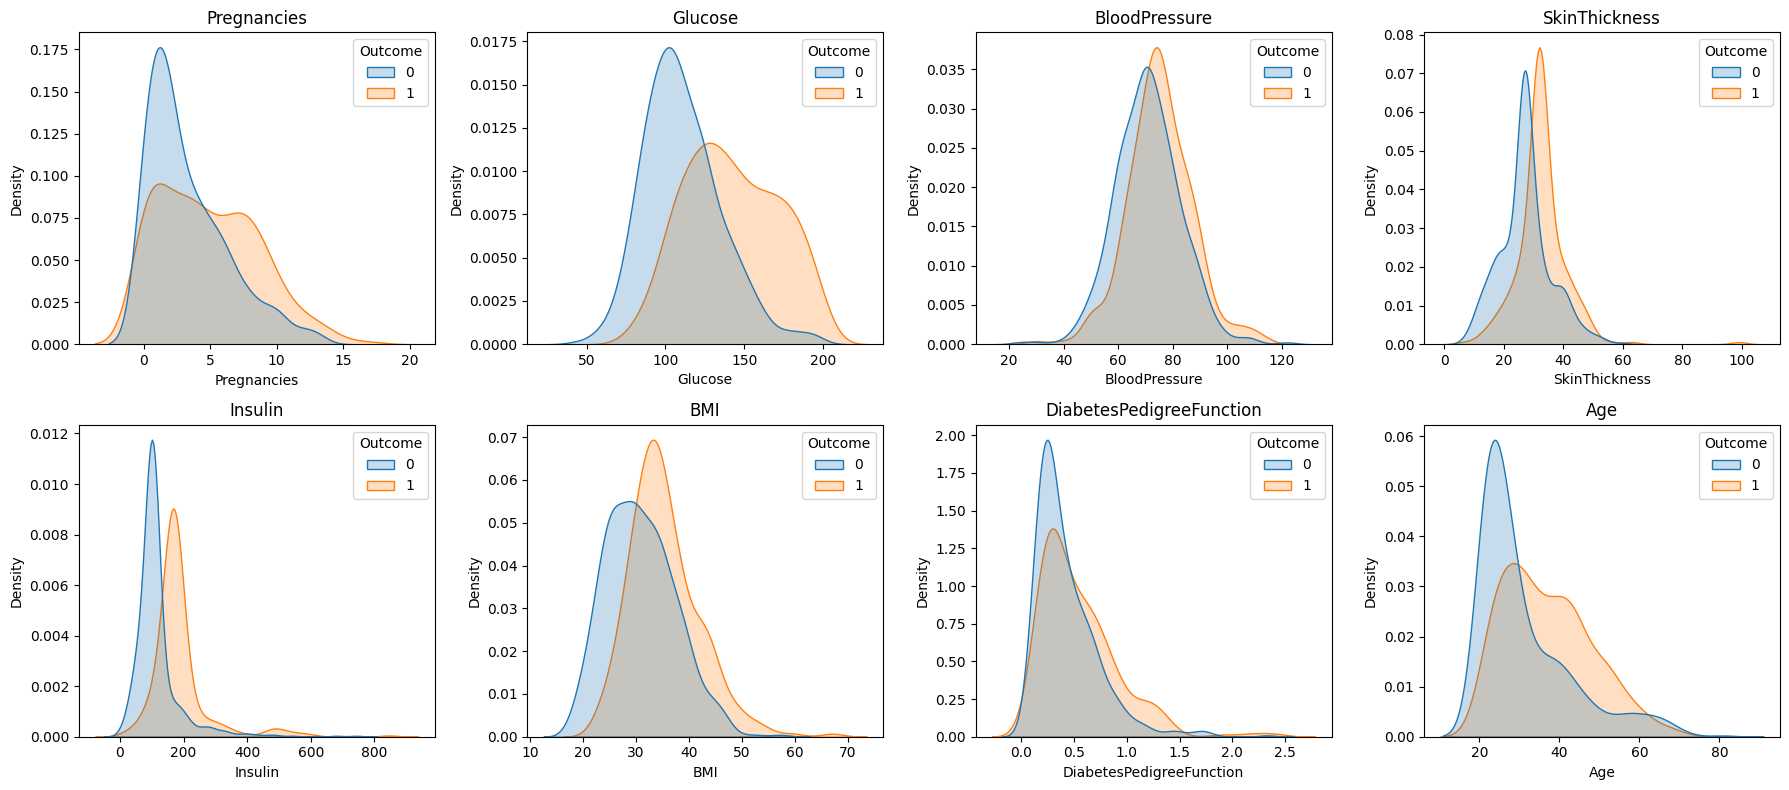

In [6]:
# Tampilkan distribusi setiap fitur menggunakan histogram atau KDE plot, dibedakan berdasarkan kelas Outcome.
features = [c for c in df.columns if c != 'Outcome']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, features):
    sns.kdeplot(data=df, x=col, hue='Outcome', fill=True, common_norm=False, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()

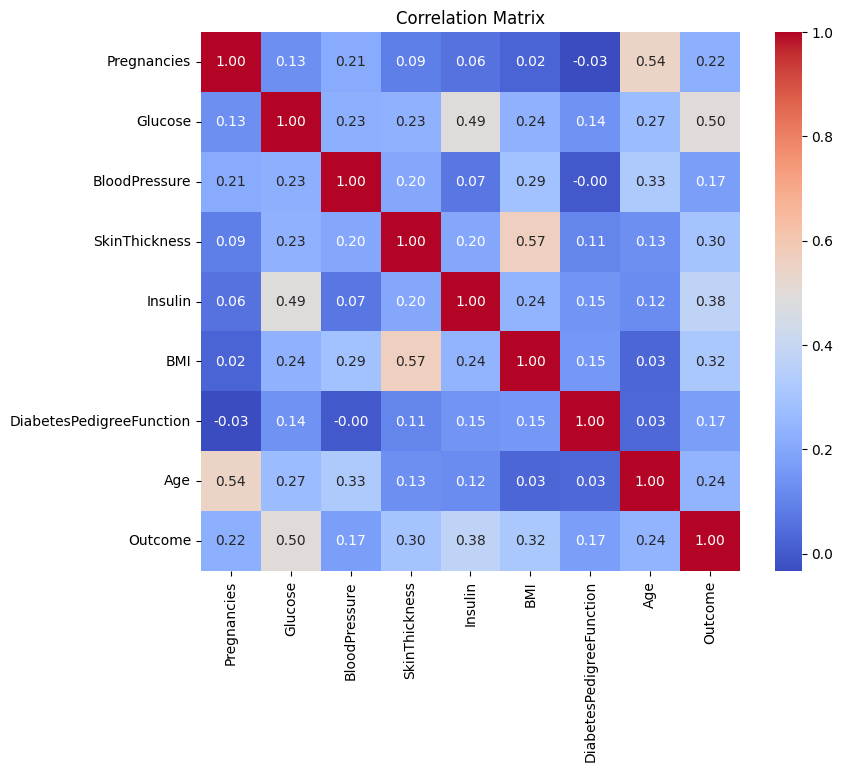

In [7]:
# Tampilkan heatmap korelasi antar fitur.
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

Jumlah baris duplikat: 0

Jumlah nilai 0 per kolom:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


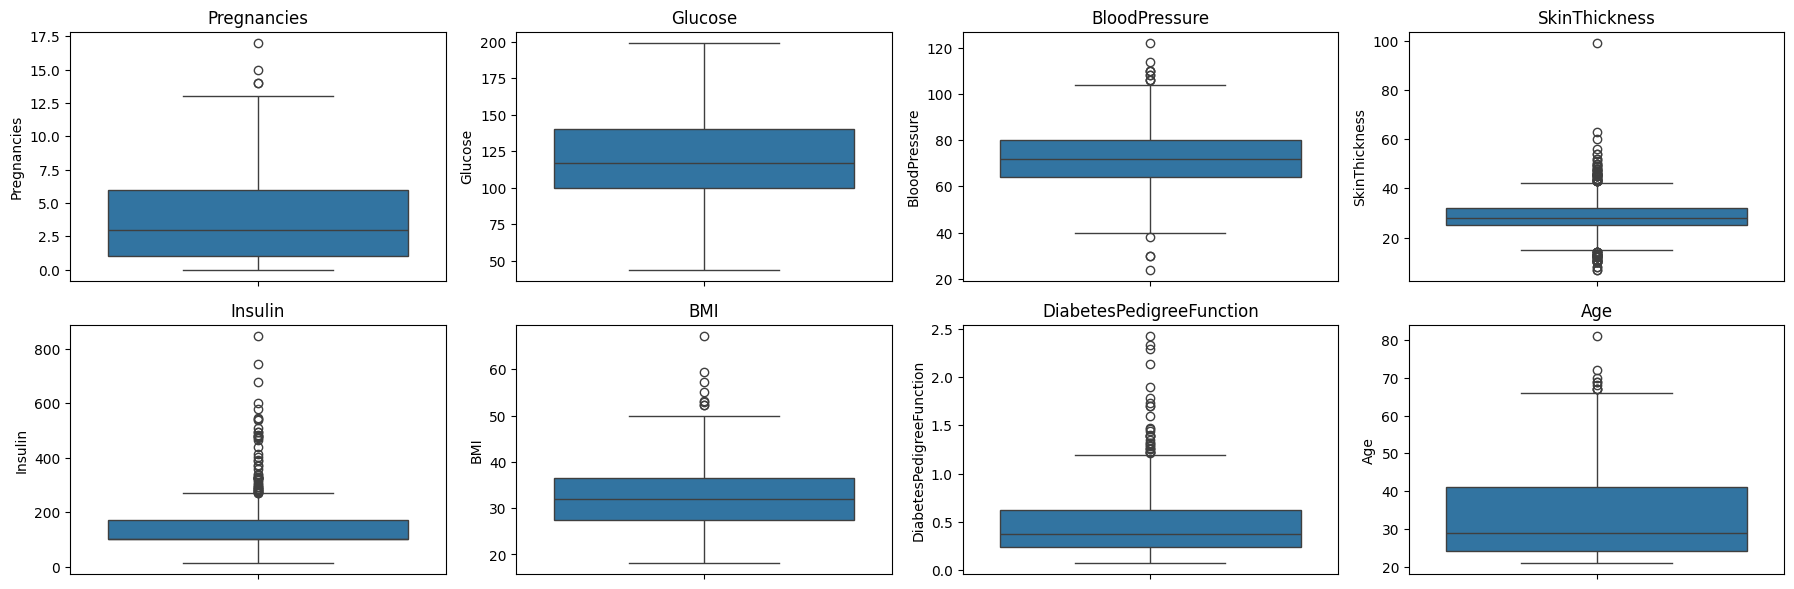

In [8]:
# Cek duplikat baris
print("Jumlah baris duplikat:", df.duplicated().sum())

# Cek nilai 0 mencurigakan (secara medis tidak mungkin) pada beberapa kolom
zero_check_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("\nJumlah nilai 0 per kolom:")
print((df[zero_check_cols] == 0).sum())

# Boxplot tiap fitur untuk cek sebaran & outlier
fig, axes = plt.subplots(2, 4, figsize=(18, 6))
axes = axes.flatten()
for ax, col in zip(axes, features):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

# 2. Preprocessing

In [9]:
# Beberapa kolom seperti Glucose, BloodPressure, SkinThickness, Insulin, dan BMI memiliki nilai 0 yang secara medis tidak mungkin.
# Identifikasi kolom-kolom tersebut dan hitung jumlah nilai 0 pada masing-masing kolom.
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
(df[zero_cols] == 0).sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

In [10]:
# Tangani nilai 0 tersebut dengan strategi yang sesuai (misalnya imputasi dengan median atau mean).
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
# Tandai 0 sebagai NaN; imputasi median dilakukan setelah split (pakai median train saja).
df[zero_cols] = df[zero_cols].replace(0, np.nan)
df[zero_cols].isnull().sum()

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

In [11]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns=['Outcome'])
y = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Imputasi median dari train set saja, dipakai juga untuk test set (anti data leakage).
medians = X_train[zero_cols].median()
X_train[zero_cols] = X_train[zero_cols].fillna(medians)
X_test[zero_cols] = X_test[zero_cols].fillna(medians)

print("X_train:", X_train.shape, "| X_test:", X_test.shape)

X_train: (614, 8) | X_test: (154, 8)


In [12]:
# Lakukan feature scaling menggunakan StandardScaler.
# Fit hanya pada train set, kemudian transform pada train set dan test set.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Shape X_train_scaled:", X_train_scaled.shape)

Shape X_train_scaled: (614, 8)


# 3. Eksperimen Model

## 3.1 Gaussian Naive Bayes

Gunakan GaussianNB karena semua fitur pada dataset ini bersifat numerik kontinu.

In [13]:
# Inisialisasi dan latih model Gaussian Naive Bayes menggunakan train set.
gnb = GaussianNB()
gnb.fit(X_train_scaled, y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)number of training samples observed in each class.","ndarray[float64](2,)","[400.,214.]"
"class_prior_ class_prior_: ndarray of shape (n_classes,)probability of each class.","ndarray[float64](2,)","[0.65,0.35]"
"classes_ classes_: ndarray of shape (n_classes,)class labels known to the classifier.","ndarray[int64](2,)","[0,1]"
epsilon_ epsilon_: floatabsolute additive value to variances.,float64,1e-09
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
"theta_ theta_: ndarray of shape (n_classes, n_features)mean of each feature per class.","ndarray[float64](2, 8)","[[-0.15,-0.38,-0.14,...,-0.24,-0.12,-0.18], [ 0.28, 0.71, 0.26,..., 0.45, 0.23, 0.33]]"
"var_ var_: ndarray of shape (n_classes, n_features)Variance of each feature per class... versionadded:: 1.0","ndarray[float64](2, 8)","[[0.81,0.61,0.98,...,0.86,0.85,0.96], [1.23,0.97,0.94,...,0.94,1.2 ,0.91]]"


In [14]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_gnb = gnb.predict(X_test_scaled)
y_proba_gnb = gnb.predict_proba(X_test_scaled)[:, 1]

## 3.2 Logistic Regression

In [15]:
# Inisialisasi dan latih model Logistic Regression menggunakan train set.
logreg = LogisticRegression(random_state=42)
logreg.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solve

In [16]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label dan probabilitas kelas 1 untuk keperluan evaluasi.
y_pred_logreg = logreg.predict(X_test_scaled)
y_proba_logreg = logreg.predict_proba(X_test_scaled)[:, 1]

# 4. Evaluasi Model

In [17]:
# Tampilkan metrik evaluasi untuk setiap model: Accuracy, Precision, Recall, dan F1-Score.
results = {
    'Gaussian NB': y_pred_gnb,
    'Logistic Regression': y_pred_logreg,
}

pd.DataFrame({
    name: {
        'Accuracy': accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
    }
    for name, pred in results.items()
}).T

,Accuracy,Precision,Recall,F1-Score
Gaussian NB,0.727273,0.603448,0.648148,0.625000
Logistic Regression,0.707792,0.588235,0.555556,0.571429


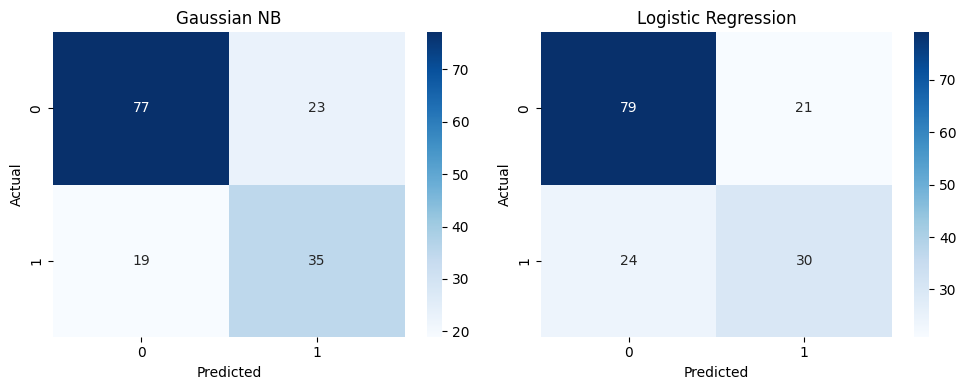

In [18]:
# Tampilkan Confusion Matrix setiap model dalam bentuk heatmap.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, pred) in zip(axes, results.items()):
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

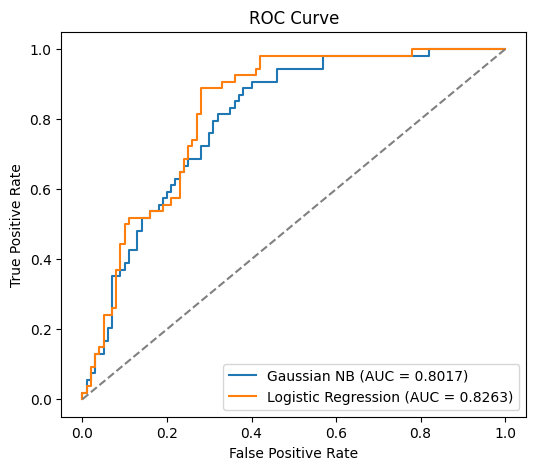

In [19]:
# Tampilkan ROC Curve kedua model dalam satu plot beserta nilai AUC masing-masing.
probas = {'Gaussian NB': y_proba_gnb, 'Logistic Regression': y_proba_logreg}

plt.figure(figsize=(6, 5))
for name, proba in probas.items():
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_score(y_test, proba):.4f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

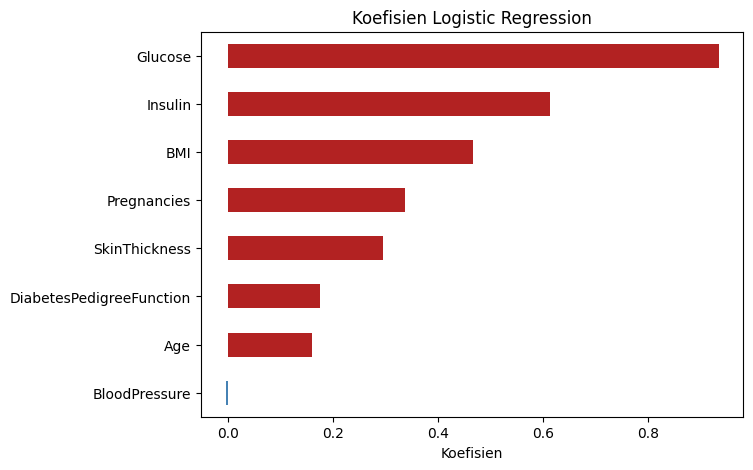

In [20]:
# Khusus Logistic Regression: tampilkan koefisien setiap fitur dalam bentuk bar chart horizontal.
# Koefisien positif menandakan fitur meningkatkan probabilitas diabetes, negatif sebaliknya.
coef = pd.Series(logreg.coef_[0], index=X.columns).sort_values()

plt.figure(figsize=(7, 5))
coef.plot(kind='barh', color=coef.map(lambda v: 'firebrick' if v > 0 else 'steelblue'))
plt.title('Koefisien Logistic Regression')
plt.xlabel('Koefisien')
plt.show()

# 5. Analisis

| Model | Accuracy | Precision | Recall | F1-Score | AUC |
|---|---|---|---|---|---|
| Gaussian NB | 0.7273 | 0.6034 | 0.6481 | 0.6250 | 0.8017 |
| Logistic Regression | 0.7078 | 0.5882 | 0.5556 | 0.5714 | 0.8263 |

- **Di threshold default 0.5, GaussianNB unggul** di semua metrik (accuracy, precision, recall, F1) dibanding Logistic Regression. Tapi **AUC Logistic Regression lebih tinggi** (0.8263 vs 0.8017) — artinya LogReg sebenarnya punya kemampuan ranking/pemisahan kelas yang lebih baik secara keseluruhan, hanya saja threshold 0.5 kurang optimal untuk precision-recall-nya di data ini.
- GaussianNB unggul di metrik berbasis threshold kemungkinan karena asumsi distribusi Gaussian per fitur cukup mendekati kenyataan sebagian besar fitur numerik di dataset ini (lihat KDE plot tahap EDA), sedangkan LogReg yang linear pada ruang fitur bisa kurang fleksibel menangkap batas keputusan yang sedikit non-linear.
- Koefisien Logistic Regression menunjukkan `Glucose` (0.93) sebagai prediktor terkuat kenaikan risiko diabetes, disusul `Insulin` (0.61) dan `BMI` (0.47) — konsisten dengan korelasi tertinggi terhadap Outcome di heatmap EDA. `BloodPressure` (-0.004) praktis tidak berkontribusi.
- Recall kedua model tergolong rendah (0.56-0.65): banyak pasien diabetes (kelas 1) yang justru diprediksi negatif (false negative), risiko besar untuk kasus medis seperti ini.

# 6. Kesimpulan dan Saran

**Kesimpulan**
- Kedua model punya performa moderat (accuracy ~71-73%), belum cukup andal untuk skrining diabetes tanpa dukungan tambahan.
- GaussianNB lebih baik di threshold default, tapi Logistic Regression punya AUC lebih tinggi — pilihan model sebaiknya mempertimbangkan threshold tuning, bukan cuma metrik default.
- `Glucose`, `Insulin`, dan `BMI` adalah fitur paling berpengaruh terhadap risiko diabetes pada dataset ini.
- Recall rendah di kedua model jadi kelemahan utama karena berisiko false negative pada kasus medis.

**Saran**
- Tuning decision threshold (bukan 0.5) untuk menaikkan recall, terutama karena AUC LogReg menunjukkan ada titik potong lebih baik.
- Uji penanganan imbalance (misal `class_weight='balanced'` pada LogReg, atau oversampling) mengingat distribusi Outcome 65:35.
- Validasi dengan k-fold cross-validation untuk estimasi performa yang lebih stabil.
- Tambah model non-linear (Decision Tree, Random Forest) untuk uji apakah batas keputusan non-linear membantu, mengingat gap recall & AUC vs accuracy kedua model saat ini.